# Analisis Regresi: OLS, WLS, GLS, Ridge, dan LASSO

Target **Y**, prediktor **X1–X30**. Urutan baris asli dipertahankan.
80% pertama untuk train, 20% terakhir untuk test. Semua diagnostik memakai
sisaan OLS train; VIF memakai prediktor train. Test hanya untuk evaluasi akhir.

Alur notebook: baca data → bagi train/test → periksa asumsi OLS → latih model →
bandingkan hasil. Variabel `X` berisi prediktor, `y` berisi target, dan
`residuals` adalah selisih nilai Y train dengan prediksi OLS.

## A. Persiapan

Gunakan Python 3.12 dan instal dependensi dari requirements.txt.
Pilih kernel dari environment tersebut, lalu jalankan seluruh sel dari awal.
Petunjuk instalasi dan lokasi data tersedia di README.md.
Array internal model OLS/WLS/GLS dilepas setelah hasil yang diperlukan dihitung
untuk menghemat memori. Jalankan dari awal jika ingin mengulang diagnostik.

In [1]:
import warnings
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.linalg import lstsq
import statsmodels
import statsmodels.api as sm
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from statsmodels.stats.stattools import jarque_bera, omni_normtest, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from threadpoolctl import threadpool_limits

blas_limits = threadpool_limits(limits=2)
rng = np.random.default_rng(42)
SIGNIFICANCE = 0.05
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.2})
print({m.__name__: m.__version__ for m in (np, pd, scipy, statsmodels, sklearn)})

{'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'statsmodels': '0.15.0', 'sklearn': '1.9.0'}


In [2]:
df = pd.read_csv('raw_data_simulasi.txt', sep=r'\s+')
features = [f'X{i}' for i in range(1, 31)]
assert list(df.columns) == features + ['Y'], 'Kolom tidak sesuai.'
assert all(pd.api.types.is_numeric_dtype(dtype) for dtype in df.dtypes)
assert np.isfinite(df.to_numpy()).all(), 'Ada nilai hilang/tak hingga.'
split = int(0.8 * len(df))
train_data = df.iloc[:split]
test_data = df.iloc[split:]
X_train = train_data[features].to_numpy(dtype=float)
X_test = test_data[features].to_numpy(dtype=float)
y_train = train_data['Y'].to_numpy(dtype=float)
y_test = test_data['Y'].to_numpy(dtype=float)
assert len(y_train) + len(y_test) == len(df)
assert np.all(X_train.std(axis=0) > 0), 'Prediktor konstan.'
display(pd.DataFrame({
    'Bagian': ['Train', 'Test'], 'n': [len(y_train), len(y_test)],
    'Baris awal (1-based)': [1, split + 1], 'Baris akhir': [split, len(df)],
    'Mean Y': [y_train.mean(), y_test.mean()],
    'SD Y': [y_train.std(ddof=1), y_test.std(ddof=1)],
}))
print('Missing:', df.isna().sum().sum(), '| Duplikat:', df.duplicated().sum())
display(df.describe().T)
del df, train_data, test_data
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')
ols_model = sm.OLS(y_train, X_train_const).fit()
residuals = np.asarray(ols_model.resid)
print(ols_model.summary(xname=['const'] + features))
display(pd.Series(residuals, name='Sisaan OLS train').describe())

,Bagian,n,Baris awal (1-based),Baris akhir,Mean Y,SD Y
0,Train,1200000,1,1200000,4.990102,6.341682
1,Test,300000,1200001,1500000,5.000974,6.328535


Missing: 0 | Duplikat: 0


,count,mean,std,min,25%,50%,75%,max
X1,1500000.0,-0.000009,1.001173,-4.980146,-0.675594,0.000543,0.674382,5.032374
X2,1500000.0,0.000102,0.906577,-4.412047,-0.612068,0.000580,0.610783,4.567443
X3,1500000.0,-0.000067,0.864471,-4.387951,-0.582589,0.000090,0.582836,4.419253
X4,1500000.0,0.000151,0.825262,-4.126122,-0.556343,0.000747,0.556327,3.798591
X5,1500000.0,-0.000160,0.791597,-3.919202,-0.534413,0.000039,0.533728,3.921457
X6,1500000.0,0.000385,0.999751,-4.841791,-0.673958,-0.000540,0.675387,4.984215
X7,1500000.0,0.000322,0.887936,-4.286573,-0.598866,-0.000267,0.599295,4.374868
X8,1500000.0,0.000245,0.839225,-4.166682,-0.565859,-0.000233,0.566090,4.067431
X9,1500000.0,0.000013,0.810461,-3.985007,-0.547175,0.000020,0.546431,3.981681
X10,1500000.0,0.000253,0.772539,-3.933748,-0.521510,-0.000908,0.521866,3.756677


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     9176.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:14:31   Log-Likelihood:            -3.7954e+06
No. Observations:             1200000   AIC:                         7.591e+06
Df Residuals:                 1199969   BIC:                         7.591e+06
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9930      0.005    956.273      0.0

count    1.200000e+06
mean    -4.226119e-15
std      5.719457e+00
min     -2.708294e+01
25%     -3.886773e+00
50%     -7.928190e-01
75%      2.989815e+00
max      9.644420e+01
Name: Sisaan OLS train, dtype: float64

## B. Uji asumsi OLS train

### 1. Normalitas

Jarque–Bera dan omnibus memakai seluruh sisaan train. Shapiro–Wilk hanya
memakai sampel acak 5.000 tanpa pengembalian. Kurtosis **Pearson**: normal = 3;
excess = kurtosis − 3. Histogram memakai semua sisaan; Q–Q memakai sampel 10.000.

,Ukuran,Nilai
0,Skewness,1.142859
1,Kurtosis Pearson,6.693090
2,Excess kurtosis,3.693090


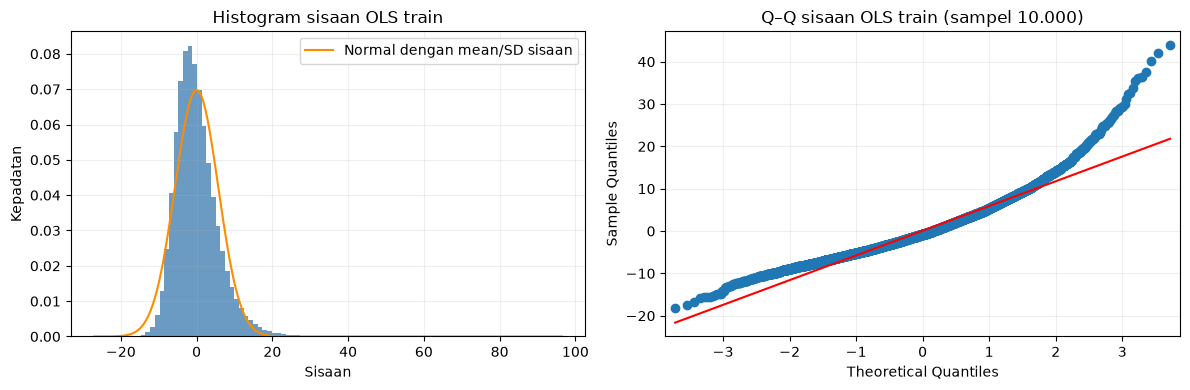

In [3]:
jb_stat, jb_p, skewness, kurtosis = jarque_bera(residuals)
omni_stat, omni_p = omni_normtest(residuals)
shapiro_idx = rng.choice(len(residuals), size=min(5000, len(residuals)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(residuals[shapiro_idx])
display(pd.DataFrame({'Ukuran': ['Skewness', 'Kurtosis Pearson', 'Excess kurtosis'],
                      'Nilai': [skewness, kurtosis, kurtosis - 3]}))
qq_idx = rng.choice(len(residuals), size=min(10000, len(residuals)), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=100, density=True, color='steelblue', alpha=0.8)
grid = np.linspace(residuals.min(), residuals.max(), 500)
axes[0].plot(grid, stats.norm.pdf(grid, residuals.mean(), residuals.std()),
             color='darkorange', label='Normal dengan mean/SD sisaan')
axes[0].set(title='Histogram sisaan OLS train', xlabel='Sisaan', ylabel='Kepadatan')
axes[0].legend()
sm.qqplot(residuals[qq_idx], line='s', ax=axes[1])
axes[1].set_title('Q–Q sisaan OLS train (sampel 10.000)')
plt.tight_layout()
plt.show()

**Interpretasi hasil:** skewness **1,143** menunjukkan sisaan menceng ke kanan.
Kurtosis Pearson **6,693** (excess **3,693**) menunjukkan ekor lebih berat daripada
normal. Histogram memperlihatkan puncak lebih tinggi daripada kurva normal pembanding;
pada Q–Q plot, terutama ekor kanan melengkung jauh di atas garis acuan.
Penyimpangan ini nyata secara bentuk, bukan sekadar akibat ukuran sampel.
Jarque–Bera, omnibus, dan Shapiro–Wilk (5.000) semuanya menolak normalitas.

Pada n besar, uji sangat sensitif, sehingga interpretasi mengutamakan besar
skewness/kurtosis dan grafik, bukan hanya p-value.

**CLT** mendukung pendekatan normal bagi distribusi estimasi koefisien pada sampel
besar apabila eksogenitas, momen yang memadai, dan independensi/ketergantungan lemah
terpenuhi. CLT tidak membuat sisaan normal atau memperbaiki standard error OLS biasa
ketika terdapat heteroskedastisitas/autokorelasi. Inferensi membutuhkan kovarians
robust yang sesuai (misalnya HAC) atau model galat yang benar.

### 2. Multikolinearitas

VIF dihitung sebagai diagonal invers korelasi prediktor train, tanpa intersep.
Ambang: **VIF > 10**. VIF tidak mempunyai p-value. Pasangan diurutkan menurut
nilai absolut korelasi, tetapi tanda korelasi tetap ditampilkan.

In [4]:
corr_matrix = np.corrcoef(X_train, rowvar=False)
assert np.linalg.matrix_rank(corr_matrix) == len(features), 'Kolinearitas sempurna.'
vif_values = np.diag(np.linalg.inv(corr_matrix))
vif_table = pd.DataFrame({'Variabel': features, 'VIF': vif_values, 'VIF > 10': vif_values > 10})
display(vif_table.sort_values('VIF', ascending=False))
i, j = np.triu_indices(len(features), k=1)
correlation_pairs = pd.DataFrame({
    'Variabel 1': np.array(features)[i], 'Variabel 2': np.array(features)[j],
    'Korelasi': corr_matrix[i, j], 'Absolut korelasi': np.abs(corr_matrix[i, j]),
}).sort_values('Absolut korelasi', ascending=False)
display(correlation_pairs.head(10))

,Variabel,VIF,VIF > 10
27,X28,334.165657,True
28,X29,329.216859,True
26,X27,298.656722,True
25,X26,289.920073,True
10,X11,202.252695,True
0,X1,139.640789,True
11,X12,133.250346,True
5,X6,94.530968,True
1,X2,82.126738,True
18,X19,76.999949,True


,Variabel 1,Variabel 2,Korelasi,Absolut korelasi
245,X11,X12,0.996241,0.996241
0,X1,X2,0.993893,0.993893
432,X28,X29,0.992370,0.992370
135,X6,X7,0.990806,0.990806
246,X11,X13,0.989011,0.989011
264,X12,X13,0.985290,0.985290
1,X1,X3,0.984837,0.984837
425,X26,X27,0.983140,0.983140
29,X2,X3,0.978796,0.978796
136,X6,X8,0.976710,0.976710


### 3. Heteroskedastisitas

H0: ragam galat konstan. Breusch–Pagan memakai seluruh train (versi Koenker,
robust=True). White memakai sampel acak **50.000 baris**, dengan indeks X dan
sisaan yang sama. het_white membentuk kuadrat dan interaksi sendiri.
Autokorelasi dapat memengaruhi kalibrasi p-value BP/White; ini hasil diagnostik.

,Uji,LM,p-value LM,F,p-value F
0,Breusch–Pagan (Koenker),31.217601,4.047665e-01,1.040587,4.047682e-01
1,White (50.000),2678.786744,1.136374e-295,5.661316,1.931639e-306


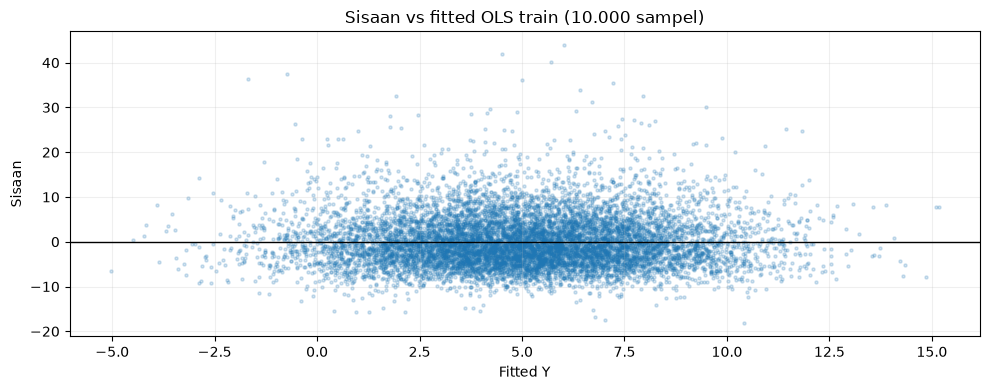

In [5]:
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_train_const, robust=True)
white_idx = rng.choice(len(residuals), size=min(50000, len(residuals)), replace=False)
white_lm, white_p, white_f, white_fp = het_white(residuals[white_idx], X_train_const[white_idx])
display(pd.DataFrame({
    'Uji': ['Breusch–Pagan (Koenker)', 'White (50.000)'],
    'LM': [bp_lm, white_lm], 'p-value LM': [bp_p, white_p],
    'F': [bp_f, white_f], 'p-value F': [bp_fp, white_fp],
}))
fig, ax = plt.subplots()
ax.scatter(ols_model.fittedvalues[qq_idx], residuals[qq_idx], s=5, alpha=0.2)
ax.axhline(0, color='black', linewidth=1)
ax.set(title='Sisaan vs fitted OLS train (10.000 sampel)', xlabel='Fitted Y', ylabel='Sisaan')
plt.tight_layout()
plt.show()

### 4. Autokorelasi

Sisaan train tetap dalam urutan asli. BG memakai 10 lag; ACF/PACF sampai lag 40.
Urutan baris dianggap urutan observasi tanpa mengasumsikan interval kalender.
Ljung–Box dihitung manual dari ACF berbasis FFT:

$$Q(h)=n(n+2)\sum_{k=1}^{h}\frac{\hat r_k^2}{n-k},\qquad
p=P(\chi_h^2\ge Q(h)).$$

Derajat bebas h digunakan sebagai diagnostik regresi (model_df=0), bukan
penyesuaian ARMA. DW tidak memiliki p-value universal; nilai dekat 2 menunjukkan
autokorelasi lag 1 kecil. Keputusan formal memakai BG/Ljung–Box.
Pita ACF/PACF ±1,96/√n adalah pendekatan titik per titik, bukan interval simultan.

DW OLS = 0.600042; BG(10) LM = 587985.467; p-value = 0


,Lag,Q,p-value
0,10,1.149758e+06,0.0
1,20,1.150525e+06,0.0
2,40,1.150543e+06,0.0


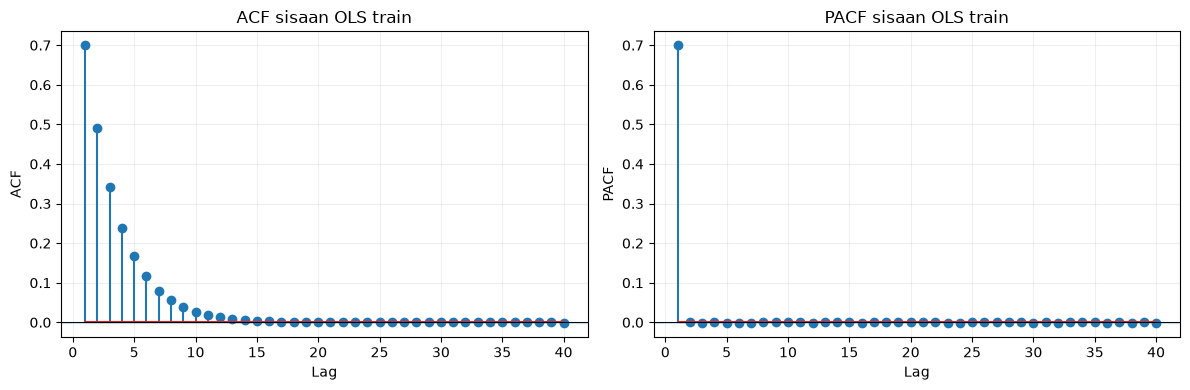

In [6]:
dw_ols = durbin_watson(residuals)
bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(ols_model, nlags=10, result_object=False)
max_lag = 40
acf_values = acf(residuals, nlags=max_lag, fft=True)
pacf_values = pacf(residuals, nlags=max_lag, method='ywm')
lags = np.arange(1, max_lag + 1)
n_train = len(residuals)
# Setiap Q(h) menjumlahkan kontribusi ACF dari lag 1 sampai h.
acf_contributions = acf_values[1:] ** 2 / (n_train - lags)
q_values = n_train * (n_train + 2) * np.cumsum(acf_contributions)
lb_lags = np.array([10, 20, 40])
lb_table = pd.DataFrame({'Lag': lb_lags, 'Q': q_values[lb_lags - 1],
                        'p-value': stats.chi2.sf(q_values[lb_lags - 1], df=lb_lags)})
print(f'DW OLS = {dw_ols:.6f}; BG(10) LM = {bg_lm:.3f}; p-value = {bg_p:.6g}')
display(lb_table)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, values, title in zip(axes, [acf_values, pacf_values], ['ACF', 'PACF']):
    ax.stem(lags, values[1:])
    ax.axhspan(-1.96 / np.sqrt(n_train), 1.96 / np.sqrt(n_train), color='steelblue', alpha=0.2)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set(title=f'{title} sisaan OLS train', xlabel='Lag', ylabel=title)
plt.tight_layout()
plt.show()

### 5. Ringkasan asumsi

Taraf signifikansi 5%. H0 normalitas: sisaan normal; H0 homoskedastisitas: ragam
konstan; H0 autokorelasi: tidak ada autokorelasi sampai lag yang diuji.
P-value 0 berarti terlalu kecil untuk representasi numerik, bukan peluang tepat nol.

In [7]:
assumption_rows = []
for assumption, test, statistic, p in [
    ('Normalitas', 'Jarque–Bera', jb_stat, jb_p),
    ('Normalitas', 'Omnibus', omni_stat, omni_p),
    ('Normalitas', 'Shapiro–Wilk (5.000)', shapiro_stat, shapiro_p),
    ('Homoskedastisitas', 'Breusch–Pagan LM', bp_lm, bp_p),
    ('Homoskedastisitas', 'White LM (50.000)', white_lm, white_p),
    ('Tidak ada autokorelasi', 'Breusch–Godfrey LM (10)', bg_lm, bg_p),
]:
    assumption_rows.append([assumption, test, statistic, p,
                            'Tolak H0' if p < SIGNIFICANCE else 'Gagal menolak H0'])
for lag, q, p in lb_table.itertuples(index=False, name=None):
    assumption_rows.append(['Tidak ada autokorelasi', f'Ljung–Box ({int(lag)}) manual', q, p,
                            'Tolak H0' if p < SIGNIFICANCE else 'Gagal menolak H0'])
assumption_rows += [
    ['Multikolinearitas', 'VIF maksimum', vif_values.max(), np.nan,
     f'{int((vif_values > 10).sum())} prediktor VIF > 10'],
    ['Tidak ada autokorelasi', 'Durbin–Watson', dw_ols, np.nan, 'Deskriptif; lihat BG/LB'],
]
assumption_summary = pd.DataFrame(assumption_rows, columns=['Asumsi', 'Uji', 'Statistik', 'p-value', 'Keputusan'])
display(assumption_summary)
# Diagnostik OLS selesai; koefisien dan statistik skalar tetap tersedia.
ols_model.remove_data()

,Asumsi,Uji,Statistik,p-value,Keputusan
0,Normalitas,Jarque–Bera,9.431709e+05,0.000000e+00,Tolak H0
1,Normalitas,Omnibus,2.748534e+05,0.000000e+00,Tolak H0
2,Normalitas,Shapiro–Wilk (5.000),9.485932e-01,1.132233e-38,Tolak H0
3,Homoskedastisitas,Breusch–Pagan LM,3.121760e+01,4.047665e-01,Gagal menolak H0
4,Homoskedastisitas,White LM (50.000),2.678787e+03,1.136374e-295,Tolak H0
5,Tidak ada autokorelasi,Breusch–Godfrey LM (10),5.879855e+05,0.000000e+00,Tolak H0
6,Tidak ada autokorelasi,Ljung–Box (10) manual,1.149758e+06,0.000000e+00,Tolak H0
7,Tidak ada autokorelasi,Ljung–Box (20) manual,1.150525e+06,0.000000e+00,Tolak H0
8,Tidak ada autokorelasi,Ljung–Box (40) manual,1.150543e+06,0.000000e+00,Tolak H0
9,Multikolinearitas,VIF maksimum,3.341657e+02,NaN,27 prediktor VIF > 10


## C. Model

### 1. OLS

Menggunakan ols_model dari bagian A, hanya fit pada train.

### 2. WLS

WLS (*Weighted Least Squares*) memberi bobot berbeda pada setiap baris.
Baris yang galatnya diperkirakan lebih besar diberi bobot lebih kecil, sehingga
tidak terlalu memengaruhi koefisien regresi. Langkahnya:

1. Ambil sisaan `e` dari OLS pada data train. Kuadratnya, `e²`, dipakai sebagai
   petunjuk besar ragam galat.
2. Latih model kedua untuk memperkirakan `ln(e²)` dari intersep, X, dan kuadrat
   masing-masing X (tanpa interaksi). Log membantu menjaga perkiraan ragam
   tetap positif setelah dikembalikan dengan `exp`.
3. Hitung bobot `1 / ragam_prediksi` untuk setiap baris train. Misalnya, ragam
   prediksi 4 mendapat bobot 0,25; ragam 2 mendapat bobot 0,5.
4. Fit ulang regresi Y terhadap X dengan bobot tersebut.

Nilai `e²` yang nol diberi batas bawah kecil agar `log(0)` tidak terjadi.
Model ragam dan bobot hanya dibuat dari data train. `exp` di sini memberi
pendekatan **ragam relatif**; faktor koreksi konstan tidak mengubah koefisien
WLS. WLS adalah kasus khusus GLS ketika matriks kovarians Σ diagonal.

In [8]:
# Model ragam memakai X dan X² untuk memperkirakan besar galat.
variance_X = np.column_stack([X_train_const, X_train ** 2])
residual_floor = np.finfo(float).eps * max(float(np.mean(residuals ** 2)), 1.0)
# Hindari log(0), lalu pelajari hubungan X dengan log kuadrat sisaan.
log_squared_residuals = np.log(np.maximum(residuals ** 2, residual_floor))
# Least squares berbasis QR berpivot: OLS yang sama tanpa pseudoinvers 61×n.
variance_coef = lstsq(variance_X, log_squared_residuals, lapack_driver="gelsy")[0]
log_variance = variance_X @ variance_coef
# Lepaskan matriks bantu sebelum fit WLS agar tidak menumpuk di memori.
del variance_X, log_squared_residuals, variance_coef
assert np.isfinite(log_variance).all() and np.max(np.abs(log_variance)) < 700
# exp mengembalikan hasil model ke skala ragam yang positif.
predicted_variance = np.exp(log_variance)
# Observasi dengan ragam prediksi lebih besar mendapat bobot lebih kecil.
weights = 1.0 / predicted_variance
assert np.isfinite(weights).all() and np.all(weights > 0)
# Fit ulang model utama dengan bobot dari perkiraan ragam.
wls_model = sm.WLS(y_train, X_train_const, weights=weights).fit()
display(pd.Series(weights, name='Bobot WLS').describe())
# Hitung AIC/nobs sebelum array model dilepas; keduanya tetap tersedia di bagian D.
_ = wls_model.aic, wls_model.nobs
wls_model.remove_data()
del log_variance, predicted_variance

count    1.200000e+06
mean     1.307096e-01
std      2.973457e-02
min      5.381016e-04
25%      1.169473e-01
50%      1.418916e-01
75%      1.532195e-01
max      1.713874e-01
Name: Bobot WLS, dtype: float64

### 3. GLS biasa: AR(1) dua tahap

Model utama: $y=X\beta+\varepsilon$, dengan
$\varepsilon\sim N(0,\sigma^2\Omega)$ dan
$\Omega_{ij}=\rho^{|i-j|}/(1-\rho^2)$.
Estimator GLS adalah
$\hat\beta=(X'\Omega^{-1}X)^{-1}X'\Omega^{-1}y$.
Tahap pertama mengestimasi korelasi **hanya dari sisaan OLS train**, tanpa iterasi:

$$\hat\rho=\frac{\sum_{t=2}^n e_t e_{t-1}}{\sum_{t=1}^{n-1}e_t^2}.$$

Nilai $1-DW/2$ dipakai sebagai pengecekan pendekatan. Tahap kedua memakai
transformasi Prais–Winsten $P$, sehingga $P'P=\Omega^{-1}$:

$$y_1^*=\sqrt{1-\hat\rho^2}\,y_1,\qquad
y_t^*=y_t-\hat\rho y_{t-1}\quad(t\ge2).$$

Semua kolom X, **termasuk konstanta**, ditransformasi dengan aturan yang sama;
lag memakai nilai asli, bukan nilai yang sudah ditransformasi. Observasi pertama
tetap dipertahankan. Tidak ada matriks n×n pada data penuh: untuk 1,2 juta baris,
matriks float64 akan membutuhkan sekitar 11,5 TB.

OLS pada $(y^*,X^*)$ menghasilkan koefisien dan standard error GLS, dengan
ρ̂ diperlakukan tetap. **R² dan F objek OLS transformasi tidak digunakan** karena
kolom konstanta ikut berubah. Prediksi tetap $X\hat\beta$ pada skala Y asli.
DW dihitung dari sisaan setelah transformasi dan diharapkan mendekati 2.

Likelihood Gaussian memakai seluruh n observasi dan suku Jacobian:

$$\ell=-\frac n2\left[\ln(2\pi)+\ln(RSS^*/n)+1\right]
+\frac12\ln(1-\hat\rho^2),\qquad AIC=-2\ell+2k.$$

Konvensi $k=31$ menghitung intersep dan 30 slope; **ρ̂ tidak dihitung sebagai
parameter tambahan**, sama dengan konvensi AIC model lain. Ketidakpastian tahap
estimasi ρ̂ juga tidak ditambahkan pada standard error bersyarat ini.

In [9]:
def prais_winsten(values, rho):
    """Transformasi AR(1) vektorisasi; baris pertama tetap dipertahankan."""
    assert np.isfinite(rho) and abs(rho) < 1, 'Rho harus stasioner.'
    transformed = np.empty_like(values, dtype=float)
    # Baris pertama memakai faktor khusus; baris berikutnya dikurangi lag sebelumnya.
    transformed[0] = np.sqrt(1 - rho ** 2) * values[0]
    transformed[1:] = values[1:] - rho * values[:-1]
    return transformed


def gls_likelihood(rss_star, n, rho, k):
    """Likelihood penuh dengan Jacobian Prais–Winsten dan AIC bersyarat rho."""
    llf = -0.5 * n * (np.log(2 * np.pi) + np.log(rss_star / n) + 1)
    llf += 0.5 * np.log1p(-rho ** 2)
    return llf, -2 * llf + 2 * k


# Rho diestimasi dari pasangan sisaan berurutan pada data train.
previous_residuals = residuals[:-1]
current_residuals = residuals[1:]
rho_hat = float((current_residuals @ previous_residuals) /
                (previous_residuals @ previous_residuals))
rho_dw = 1 - dw_ols / 2
gls_y_star = prais_winsten(y_train, rho_hat)
gls_X_star = prais_winsten(X_train_const, rho_hat)
gls_model = sm.OLS(gls_y_star, gls_X_star).fit()
gls_k = X_train_const.shape[1]
assert gls_k == 31 and gls_model.model.rank == gls_k
assert gls_model.nobs == len(y_train)
gls_llf, gls_aic = gls_likelihood(gls_model.ssr, len(y_train), rho_hat, gls_k)
gls_residuals = y_train - X_train_const @ gls_model.params
dw_gls_raw = durbin_watson(gls_residuals)
dw_gls_whitened = durbin_watson(gls_model.resid)
np.testing.assert_allclose(gls_model.resid, prais_winsten(gls_residuals, rho_hat),
                           rtol=1e-9, atol=1e-9)
assert abs(dw_gls_whitened - 2) < 0.05, 'DW GLS setelah transformasi belum dekat 2.'
display(pd.DataFrame({'Estimasi rho': ['Dua tahap dari sisaan train', 'Pendekatan 1 − DW/2'],
                      'Nilai': [rho_hat, rho_dw]}))
print(f'Selisih rho dua tahap − pendekatan DW: {rho_hat - rho_dw:.10f}')
display(pd.DataFrame({'Sisaan': ['OLS asli', 'GLS asli', 'GLS setelah Prais–Winsten'],
                      'DW': [dw_ols, dw_gls_raw, dw_gls_whitened]}))
display(pd.DataFrame({'Koefisien GLS': gls_model.params, 'Standard error GLS': gls_model.bse},
                     index=['const'] + features))
print(f'GLS: log-likelihood penuh = {gls_llf:.6f}; AIC = {gls_aic:.6f}')

,Estimasi rho,Nilai
0,Dua tahap dari sisaan train,0.699979
1,Pendekatan 1 − DW/2,0.699979


Selisih rho dua tahap − pendekatan DW: 0.0000000166


,Sisaan,DW
0,OLS asli,0.600042
1,GLS asli,0.599991
2,GLS setelah Prais–Winsten,2.000474


,Koefisien GLS,Standard error GLS
const,4.992937,0.012428
X1,2.964125,0.036062
X2,0.032311,0.030533
X3,-0.005901,0.020363
X4,-2.481591,0.015266
X5,-0.006879,0.012216
X6,1.805790,0.029714
X7,0.008755,0.025435
X8,-0.003561,0.016967
X9,-1.217926,0.013868


GLS: log-likelihood penuh = -3391371.368533; AIC = 6782804.737066


#### Validasi GLS eksplisit dan Prais–Winsten

Pada 2.000 baris pertama train, Ω dibentuk secara eksplisit dengan ρ̂ yang sama
dari tahap OLS train penuh. Koefisien, standard error, likelihood, dan AIC
dibandingkan dengan `sm.GLS`. Ini memeriksa bahwa GLS eksplisit pada n kecil
dan transformasi pada n besar adalah estimator yang identik.

In [10]:
from scipy.linalg import toeplitz

gls_m = 2000
assert len(y_train) >= gls_m
gls_subset_y = y_train[:gls_m]
gls_subset_X = X_train_const[:gls_m]
gls_subset_omega = toeplitz(rho_hat ** np.arange(gls_m)) / (1 - rho_hat ** 2)
gls_explicit = sm.GLS(gls_subset_y, gls_subset_X, sigma=gls_subset_omega).fit()
gls_subset_pw = sm.OLS(prais_winsten(gls_subset_y, rho_hat),
                       prais_winsten(gls_subset_X, rho_hat)).fit()
gls_subset_llf, gls_subset_aic = gls_likelihood(gls_subset_pw.ssr, gls_m, rho_hat, gls_k)
np.testing.assert_allclose(gls_subset_pw.params, gls_explicit.params, rtol=1e-8, atol=0)
np.testing.assert_allclose(gls_subset_pw.bse, gls_explicit.bse, rtol=1e-8, atol=0)
np.testing.assert_allclose(gls_subset_llf, gls_explicit.llf, rtol=1e-12, atol=1e-8)
np.testing.assert_allclose(gls_subset_aic, gls_explicit.aic, rtol=1e-12, atol=1e-8)
display(pd.DataFrame({
    'Metode': ['GLS eksplisit', 'Prais–Winsten'],
    'Log-likelihood': [gls_explicit.llf, gls_subset_llf],
    'AIC': [gls_explicit.aic, gls_subset_aic],
}))
print(f'Maks |selisih koefisien|: {np.max(np.abs(gls_subset_pw.params - gls_explicit.params)):.3e}')
print('Assert koefisien, standard error, likelihood, dan AIC subset: lulus.')
del gls_subset_omega, gls_explicit, gls_subset_pw
# Koefisien, SE, likelihood, dan validasi GLS sudah dihitung.
gls_model.remove_data()
del gls_y_star, gls_X_star

,Metode,Log-likelihood,AIC
0,GLS eksplisit,-5718.080123,11498.160245
1,Prais–Winsten,-5718.080123,11498.160245


Maks |selisih koefisien|: 1.976e-14
Assert koefisien, standard error, likelihood, dan AIC subset: lulus.


### 4. Ridge

Pipeline mempelajari StandardScaler hanya pada train setiap fold.
TimeSeriesSplit(5) memakai train berkembang dengan validasi sesudahnya.
Grid alpha 10⁻⁴ sampai 10⁶ dipilih berdasarkan rata-rata RMSE validasi minimum,
lalu refit pada seluruh train. Test tidak dipakai memilih alpha.
Gap=0 mengevaluasi blok berikutnya; dependensi di batas fold tetap mungkin terjadi.

Koefisien asli βⱼ = βⱼ,standar/sⱼ; intersep asli = intersep standar − Σμⱼβⱼ.

In [11]:
tscv = TimeSeriesSplit(n_splits=5)
fold_rows = []
for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_train), start=1):
    assert train_idx.max() < valid_idx.min() and valid_idx.max() < split
    fold_rows.append([
        fold, len(train_idx), len(valid_idx),
        train_idx[-1] + 1, valid_idx[0] + 1, valid_idx[-1] + 1,
    ])
display(pd.DataFrame(fold_rows, columns=['Fold', 'n train', 'n validasi', 'Akhir train', 'Awal validasi', 'Akhir validasi']))
ridge_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(solver='cholesky'))]),
    param_grid={'ridge__alpha': np.logspace(-4, 6, 11)},
    scoring='neg_root_mean_squared_error', cv=tscv, n_jobs=1, refit=True,
    error_score='raise',
)
ridge_search.fit(X_train, y_train)
best_alpha = float(ridge_search.best_params_['ridge__alpha'])
ridge_pipeline = ridge_search.best_estimator_
scaler = ridge_pipeline.named_steps['scaler']
ridge = ridge_pipeline.named_steps['ridge']
# Kembalikan koefisien Ridge dari skala standar ke skala X asli.
ridge_coef = ridge.coef_ / scaler.scale_
ridge_intercept = ridge.intercept_ - scaler.mean_ @ ridge_coef
ridge_params = np.r_[ridge_intercept, ridge_coef]
ridge_cv = pd.DataFrame({
    'alpha': np.asarray(ridge_search.cv_results_['param_ridge__alpha'], dtype=float),
    'RMSE validasi rata-rata': -ridge_search.cv_results_['mean_test_score'],
    'SD antar-fold': ridge_search.cv_results_['std_test_score'],
})
display(ridge_cv)
print(f'Alpha terpilih: {best_alpha:g}')
if best_alpha in (ridge_cv.alpha.min(), ridge_cv.alpha.max()):
    print('Optimum di batas grid: alpha terbaik hanya berlaku untuk grid ini.')

,Fold,n train,n validasi,Akhir train,Awal validasi,Akhir validasi
0,1,200000,200000,200000,200001,400000
1,2,400000,200000,400000,400001,600000
2,3,600000,200000,600000,600001,800000
3,4,800000,200000,800000,800001,1000000
4,5,1000000,200000,1000000,1000001,1200000


,alpha,RMSE validasi rata-rata,SD antar-fold
0,0.0001,5.718234,0.019885
1,0.0010,5.718234,0.019885
2,0.0100,5.718234,0.019885
3,0.1000,5.718234,0.019885
4,1.0000,5.718234,0.019885
5,10.0000,5.718235,0.019885
6,100.0000,5.718263,0.019867
7,1000.0000,5.719068,0.019459
8,10000.0000,5.726949,0.017229
9,100000.0000,5.759530,0.015621


Alpha terpilih: 0.0001
Optimum di batas grid: alpha terbaik hanya berlaku untuk grid ini.


### 5. LASSO: penyusutan koefisien dan seleksi fitur

LASSO (*Least Absolute Shrinkage and Selection Operator*) menambahkan penalti
**L1**, yaitu jumlah nilai absolut koefisien, ke kesalahan regresi. Tujuannya
menjaga prediksi tetap baik sambil membatasi besar koefisien. Beberapa koefisien
bisa menjadi **tepat nol**, sehingga prediktor tersebut tidak dipakai dalam
prediksi. Ridge memakai penalti L2 (kuadrat koefisien) dan biasanya hanya
mengecilkan koefisien. [Dokumentasi LASSO](https://scikit-learn.org/stable/modules/linear_model.html#lasso)

Pada prediktor terstandar $z_{ij}$, model meminimumkan:

$$\frac{1}{2n}\sum_{i=1}^{n}
\left(y_i-b_0-\sum_{j=1}^{30}z_{ij}\theta_j\right)^2
+\alpha\sum_{j=1}^{30}|\theta_j|.$$

Bagian pertama mengukur kesalahan prediksi; bagian kedua membatasi koefisien.
**Intersep $b_0$ tidak dipenalti.** Semakin besar $\alpha$, semakin kuat
penyusutan; model cenderung lebih sederhana, tetapi penalti terlalu besar bisa
menghilangkan informasi yang berguna. Angka alpha LASSO dan Ridge tidak
dibandingkan langsung karena bentuk dan normalisasi objektifnya berbeda.
[Rumus objektif LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

Langkah pengerjaan:

1. Standardisasi X melalui pipeline: mean 0 dan simpangan baku 1, supaya penalti
   tidak bergantung pada satuan prediktor. Scaler hanya belajar dari train
   masing-masing fold.
2. Coba 11 alpha dari $10^{-4}$ sampai $10^1$ memakai lima fold berurutan
   yang sama dengan Ridge.
3. Pilih alpha dengan **rata-rata RMSE validasi paling kecil**, lalu fit ulang
   pada seluruh train. Data test tetap untuk evaluasi akhir di bagian D.
4. Kembalikan koefisien ke skala X asli, seperti Ridge, lalu periksa koefisien
   mana yang nol. [Pipeline dan pencegahan kebocoran data](https://scikit-learn.org/stable/common_pitfalls.html)

Pemilihan variabel dapat berubah ketika prediktor saling berkorelasi kuat.
Koefisien nol tidak membuktikan variabel tidak berhubungan dengan Y.
LASSO juga tidak otomatis mengatasi heteroskedastisitas atau autokorelasi.

In [12]:
# Gunakan fold berurutan yang sudah dibuat pada bagian Ridge.
lasso_search = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        # Gram 30×30 mempercepat optimisasi pada data dengan banyak baris.
        ('lasso', Lasso(precompute=True, max_iter=20000, tol=1e-8)),
    ]),
    param_grid={'lasso__alpha': np.logspace(-4, 1, 11)},
    scoring='neg_root_mean_squared_error', cv=tscv, n_jobs=1, refit=True,
    error_score='raise',
)
# Hentikan run jika salah satu fit tidak konvergen; jangan memakai hasilnya diam-diam.
with warnings.catch_warnings():
    warnings.simplefilter('error', ConvergenceWarning)
    lasso_search.fit(X_train, y_train)

lasso_best_alpha = float(lasso_search.best_params_['lasso__alpha'])
lasso_pipeline = lasso_search.best_estimator_
lasso_scaler = lasso_pipeline.named_steps['scaler']
lasso = lasso_pipeline.named_steps['lasso']
lasso_coef = lasso.coef_ / lasso_scaler.scale_
lasso_intercept = lasso.intercept_ - lasso_scaler.mean_ @ lasso_coef
lasso_params = np.r_[lasso_intercept, lasso_coef]
lasso_active = lasso.coef_ != 0
lasso_df = 1 + int(lasso_active.sum())  # Intersep + jumlah slope yang bukan nol.
lasso_cv = pd.DataFrame({
    'alpha': np.asarray(lasso_search.cv_results_['param_lasso__alpha'], dtype=float),
    'RMSE validasi rata-rata': -lasso_search.cv_results_['mean_test_score'],
    'SD antar-fold': lasso_search.cv_results_['std_test_score'],
})
assert np.isfinite(lasso_params).all() and 1 <= lasso_df <= len(features) + 1
assert lasso.dual_gap_ <= lasso.tol * np.var(y_train) + 1e-10, 'LASSO belum konvergen.'
with pd.option_context('display.precision', 8):
    display(lasso_cv)
print(f'Alpha LASSO terpilih: {lasso_best_alpha:g}')
print(f'Prediktor dipakai: {int(lasso_active.sum())}/{len(features)}; '
      f'koefisien nol: {int((~lasso_active).sum())}.')
if lasso_best_alpha in (lasso_cv.alpha.min(), lasso_cv.alpha.max()):
    print('Optimum di batas grid: alpha terbaik hanya berlaku untuk grid ini.')

,alpha,RMSE validasi rata-rata,SD antar-fold
0,0.00010000,5.71823306,0.01988688
1,0.00031623,5.71823887,0.01988751
2,0.00100000,5.71824968,0.01989594
3,0.00316228,5.71839700,0.01991461
4,0.01000000,5.71991089,0.01993079
5,0.03162278,5.73408163,0.01984643
6,0.10000000,5.76832655,0.01976586
7,0.31622777,5.82703635,0.02004551
8,1.00000000,6.20054405,0.02106949
9,3.16227766,6.34069900,0.02120143


Alpha LASSO terpilih: 0.0001
Prediktor dipakai: 28/30; koefisien nol: 2.
Optimum di batas grid: alpha terbaik hanya berlaku untuk grid ini.


#### Cara membaca hasil LASSO

Tabel validasi di atas memilih alpha dari data train; RMSE yang lebih kecil
berarti kesalahan prediksi lebih kecil. SD antar-fold menunjukkan variasi skor
antar-blok, bukan interval kepercayaan. Garis putus-putus pada grafik menandai
alpha terpilih.

Tabel berikut menampilkan koefisien standar dan koefisien pada skala X asli.
Misalnya, koefisien asli 2 berarti kenaikan X sebesar satu unit menaikkan
prediksi Y sebesar 2, dengan prediktor lain tetap. Koefisien 0 berarti variabel
tidak menyumbang pada prediksi model ini; tanda negatif berarti arah hubungan
prediksinya berlawanan. Intersep ditampilkan terpisah dan tetap dipakai.

Model dengan lebih sedikit prediktor lebih ringkas, tetapi belum tentu
memprediksi lebih baik. Periksa **RMSE test** bersama jumlah prediktor aktif
pada bagian D.

,Variabel,Koefisien standar,Koefisien skala asli,Status
0,X1,2.994463,2.990580,Dipakai
1,X2,-0.000337,-0.000372,Dipakai
2,X3,0.000000,0.000000,Koefisien nol
3,X4,-2.065971,-2.503086,Dipakai
4,X5,0.011010,0.013904,Dipakai
5,X6,1.796258,1.797770,Dipakai
6,X7,-0.019659,-0.022152,Dipakai
7,X8,0.010880,0.012973,Dipakai
8,X9,-0.983526,-1.214055,Dipakai
9,X10,0.021523,0.027870,Dipakai


Intersep pada skala asli: 4.99294728


**Hasil seleksi fitur:** 28 prediktor
dipakai dan 2 koefisien menjadi nol.

- **Dipakai:** X1, X2, X4, X5, X6, X7, X8, X9, X10, X11, X13, X14, X15, X16, X17, X18, X19, X20, X21, X22, X23, X24, X25, X26, X27, X28, X29, X30.
- **Koefisien nol:** X3, X12.

Daftar ini berlaku untuk alpha dan data train yang digunakan; ini bukan
kesimpulan sebab-akibat tentang variabel.


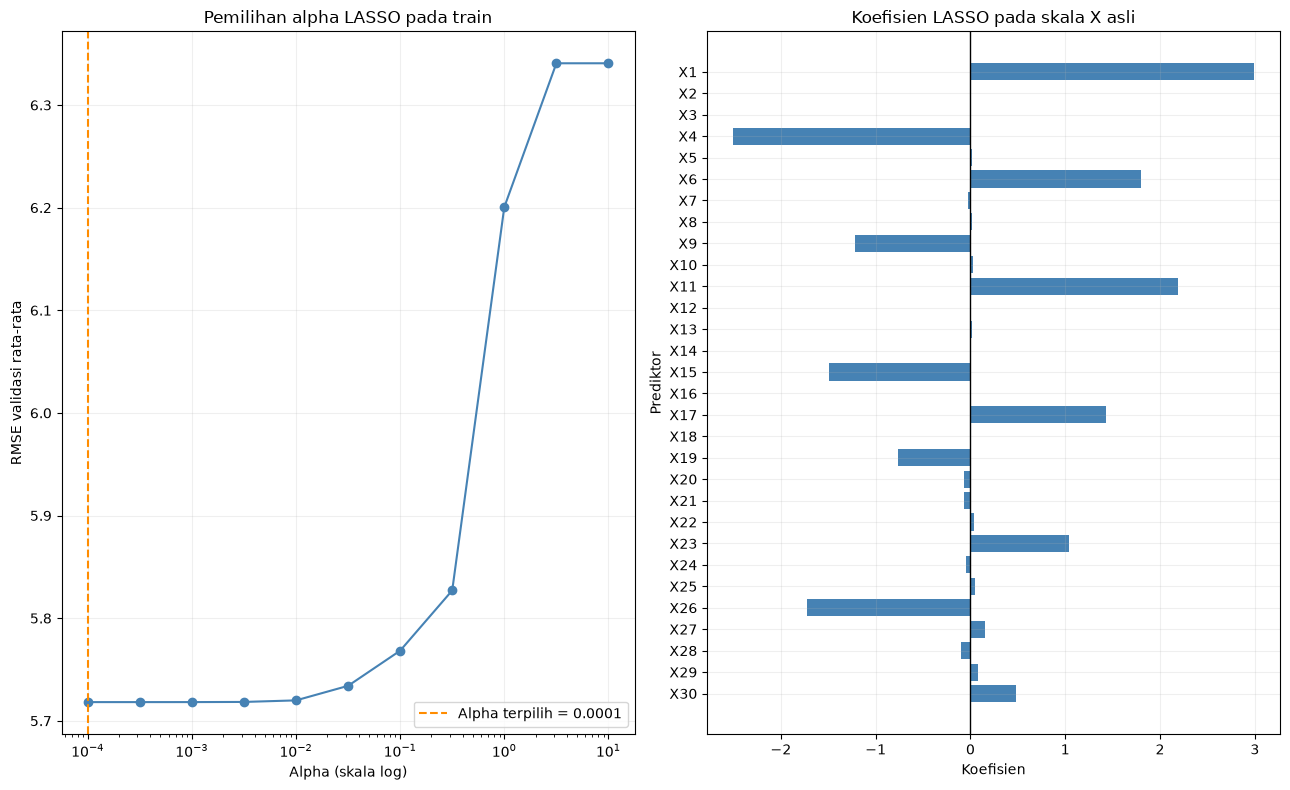

In [13]:
lasso_coefficient_table = pd.DataFrame({
    'Variabel': features,
    'Koefisien standar': lasso.coef_,
    'Koefisien skala asli': lasso_coef,
    'Status': np.where(lasso_active, 'Dipakai', 'Koefisien nol'),
})
display(lasso_coefficient_table)
print(f'Intersep pada skala asli: {lasso_intercept:.8f}')
selected_features = ', '.join(np.array(features)[lasso_active]) or 'tidak ada'
zero_features = ', '.join(np.array(features)[~lasso_active]) or 'tidak ada'
display(Markdown(f'''**Hasil seleksi fitur:** {int(lasso_active.sum())} prediktor
dipakai dan {int((~lasso_active).sum())} koefisien menjadi nol.

- **Dipakai:** {selected_features}.
- **Koefisien nol:** {zero_features}.

Daftar ini berlaku untuk alpha dan data train yang digunakan; ini bukan
kesimpulan sebab-akibat tentang variabel.
'''))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
axes[0].semilogx(lasso_cv['alpha'], lasso_cv['RMSE validasi rata-rata'],
                 marker='o', color='steelblue')
axes[0].axvline(lasso_best_alpha, color='darkorange', linestyle='--',
               label=f'Alpha terpilih = {lasso_best_alpha:g}')
axes[0].set(title='Pemilihan alpha LASSO pada train', xlabel='Alpha (skala log)',
            ylabel='RMSE validasi rata-rata')
axes[0].legend()
axes[1].barh(features, lasso_coef, color='steelblue')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].invert_yaxis()
axes[1].set(title='Koefisien LASSO pada skala X asli',
            xlabel='Koefisien', ylabel='Prediktor')
plt.tight_layout()
plt.show()

### 6. Eksplorasi: GLSAR (iteratif)

GLS biasa di atas mengestimasi ρ sekali dari OLS train, lalu melakukan satu fit GLS.
GLSAR memperbarui koefisien regresi dan ρ berulang hingga stabil/konvergen,
dengan maksimum 20 iterasi dan toleransi 10⁻⁶. Pada statsmodels, kriteria berhenti
`iterative_fit` memeriksa perubahan relatif koefisien regresi; kestabilan ρ
diperiksa terpisah di bawah. `rho=1` berarti orde AR=1, bukan nilai ρ tetap 1.

GLSAR **membuang observasi pertama**, sehingga likelihood bersyarat memakai n−1
observasi dan tidak memakai Jacobian baris awal Prais–Winsten. DW setelah
transformasi memakai `wresid`. Prediksi RMSE tetap Xβ pada skala Y asli,
tanpa koreksi galat dari Y test. Bagian ini eksplorasi tambahan, bukan model
GLS utama untuk pembahasan mata kuliah.

In [14]:
glsar_model = sm.GLSAR(y_train, X_train_const, rho=1)
glsar_results = glsar_model.iterative_fit(maxiter=20, rtol=1e-6)
glsar_rho_hat = float(glsar_model.rho[0])
glsar_dw_raw = durbin_watson(glsar_results.resid)
glsar_dw_whitened = durbin_watson(glsar_results.wresid)
glsar_rho_history = np.asarray(glsar_results.history['rho']).ravel()
assert glsar_results.converged, 'GLSAR belum konvergen.'
assert len(glsar_rho_history) >= 2
assert abs(glsar_rho_history[-1] - glsar_rho_history[-2]) < 1e-6, 'Rho GLSAR belum stabil.'
print(f'Rho GLSAR: {glsar_rho_hat:.6f}')
print('Konvergen:', glsar_results.converged, '| Iterasi:', glsar_results.iter)
display(pd.DataFrame({'Sisaan': ['OLS asli', 'GLSAR asli', 'GLSAR setelah whitening'],
                      'DW': [dw_ols, glsar_dw_raw, glsar_dw_whitened]}))
glsar_max_coef_difference = np.max(np.abs(gls_model.params - glsar_results.params))
display(pd.DataFrame({'Model': ['GLS dua tahap', 'GLSAR (eksplorasi)'],
                      'Rho': [rho_hat, glsar_rho_hat]}))
print(f'Maks |koefisien GLS − GLSAR| (termasuk intersep): {glsar_max_coef_difference:.10f}')

coefficient_table = pd.DataFrame({'OLS': ols_model.params, 'WLS': wls_model.params,
                                  'GLS': gls_model.params, 'Ridge': ridge_params,
                                  'LASSO': lasso_params,
                                  'GLSAR (eksplorasi)': glsar_results.params},
                                 index=['const'] + features)
display(coefficient_table)

Rho GLSAR: 0.700005
Konvergen: True | Iterasi: 4


,Sisaan,DW
0,OLS asli,0.600042
1,GLSAR asli,0.599991
2,GLSAR setelah whitening,2.000526


,Model,Rho
0,GLS dua tahap,0.699979
1,GLSAR (eksplorasi),0.700005


Maks |koefisien GLS − GLSAR| (termasuk intersep): 0.0000180499


,OLS,WLS,GLS,Ridge,LASSO,GLSAR (eksplorasi)
const,4.992951,4.993935,4.992937,4.992951,4.992947,4.992943
X1,3.010600,3.021641,2.964125,3.010600,2.990580,2.964129
X2,-0.018505,-0.040359,0.032311,-0.018505,-0.000372,0.032311
X3,-0.000437,0.002637,-0.005901,-0.000437,0.000000,-0.005903
X4,-2.507159,-2.501539,-2.481591,-2.507159,-2.503086,-2.481592
X5,0.013940,0.023173,-0.006879,0.013940,0.013904,-0.006880
X6,1.811161,1.788193,1.805790,1.811161,1.797770,1.805796
X7,-0.034459,-0.022532,0.008755,-0.034459,-0.022152,0.008749
X8,0.013059,0.019270,-0.003561,0.013059,0.012973,-0.003563
X9,-1.217341,-1.205841,-1.217926,-1.217341,-1.214055,-1.217926


## D. Perbandingan

RMSE train/test memakai Y asli dan Xβ untuk seluruh model. **RMSE lebih kecil**
berarti kesalahan prediksi lebih kecil; nilainya dalam satuan Y. **AIC lebih
kecil** berarti kompromi likelihood dan kompleksitas lebih baik, dengan batas
perbandingan di bawah.
AIC OLS/WLS dan GLSAR (eksplorasi) diambil dari statsmodels; AIC GLS dihitung
manual dengan likelihood penuh dan Jacobian pada bagian C.3. Untuk Ridge:

$$df_{eff}=1+\sum_j\frac{d_j^2}{d_j^2+\alpha},\qquad
AIC=n[\ln(2\pi)+\ln(RSS/n)+1]+2df_{eff}.$$

d adalah nilai singular X train terstandar; intersep tidak dipenalti. Rumus
Gaussian dicek dengan AIC OLS memakai df=rank(X dengan intersep).
AIC Ridge adalah pendekatan effective-df di bawah galat iid Gaussian.

Untuk LASSO, gunakan pendekatan **df efektif = 1 + jumlah koefisien bukan nol**;
angka 1 adalah intersep. df ini menggantikan df Ridge pada rumus Gaussian di atas.
Jumlah koefisien bukan nol mengestimasi df LASSO pada alpha tetap; pendekatan ini
mengasumsikan galat iid Gaussian dan tidak menghitung proses pemilihan alpha.
Karena diagnostik menunjukkan autokorelasi, AIC LASSO bersifat pendekatan,
sedangkan pemilihan alpha tetap berdasarkan RMSE validasi.
[Zou, Hastie, dan Tibshirani (2007)](https://arxiv.org/abs/0712.0881)

**Batas perbandingan:** GLS dan OLS memakai n observasi penuh. WLS memakai
likelihood berbobot, sedangkan GLSAR memakai likelihood bersyarat n−1 observasi.
Konvensi AIC tidak menambahkan kompleksitas estimasi bobot/ρ̂; GLS memakai k=31,
dan AIC Ridge/LASSO tidak memasukkan pencarian alpha. Minimum AIC terlapor bukan bukti
mutlak bahwa semua likelihood sebanding. GLSAR diberi label eksplorasi.

Untuk galat yang mendekati AR(1), $RSS^*/RSS_{OLS}\approx1-\hat\rho^2$.
Karena penalti k OLS dan GLS sama, secara tepat

$$\frac{AIC_{GLS}-AIC_{OLS}}n=
\ln(RSS^*/RSS_{OLS})-\frac{\ln(1-\hat\rho^2)}n.$$

Jadi **penurunan** AIC, $(AIC_{OLS}-AIC_{GLS})/n$, kira-kira
$-\ln(1-\hat\rho^2)$ per observasi, dengan koreksi batas berorde 1/n.
Ini pendekatan untuk struktur AR(1), bukan identitas untuk sembarang data.
Model struktur galat dapat menurunkan AIC besar tanpa banyak mengubah Xβ/RMSE.

,RMSE train,RMSE test,AIC,n likelihood,df mean,Delta AIC terlapor
Model,,,,,,
OLS,5.71945479,5.70119798,7.59081084e+06,1200000,31.00000000,808011.48704307
WLS,5.71946242,5.70118171,7.51521878e+06,1200000,31.00000000,732419.42326156
GLS,5.71950599,5.70117776,6.78280474e+06,1200000,31.00000000,5.38258483
Ridge,5.71945479,5.70119798,7.59081084e+06,1200000,30.99999977,808011.48704262
LASSO,5.71945853,5.70118235,7.59080841e+06,1200000,29.00000000,808009.05904081
GLSAR (eksplorasi),5.71950598,5.70117775,6.78279935e+06,1199999,31.00000000,0.00000000


Validasi AIC OLS: manual=7590810.841525, statsmodels=7590810.841525
Validasi split/CV, AIC, koefisien Ridge/LASSO, whitening, dan RMSE: lulus.


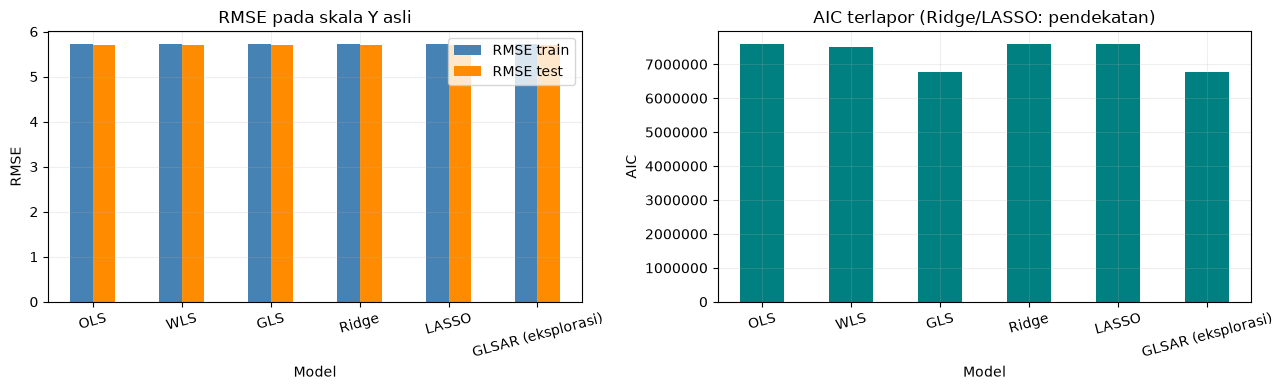

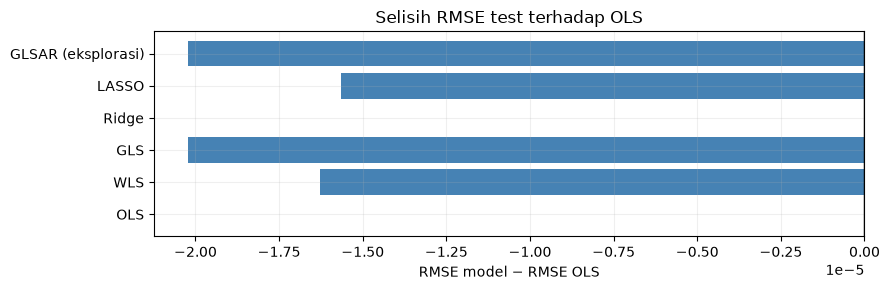

In [15]:
def gaussian_aic(rss, n, df_effective):
    return n * (np.log(2 * np.pi) + np.log(rss / n) + 1) + 2 * df_effective

# Hanya nilai singular; matriks U besar tidak disimpan.
standardized_train = scaler.transform(X_train)
singular_values = np.linalg.svd(standardized_train, compute_uv=False)
del standardized_train
ridge_df = 1 + np.sum(singular_values ** 2 / (singular_values ** 2 + best_alpha))
ols_df = int(ols_model.model.rank)
ols_aic_manual = gaussian_aic(residuals @ residuals, len(y_train), ols_df)
np.testing.assert_allclose(ols_aic_manual, ols_model.aic, rtol=1e-12, atol=1e-6)
np.testing.assert_allclose(X_test_const @ ridge_params, ridge_pipeline.predict(X_test), rtol=1e-10, atol=1e-10)
# Pastikan pengembalian koefisien LASSO ke skala asli tidak mengubah prediksi.
np.testing.assert_allclose(X_test_const @ lasso_params, lasso_pipeline.predict(X_test), rtol=1e-10, atol=1e-10)
assert 1 <= ridge_df <= X_train_const.shape[1]
np.testing.assert_allclose(glsar_results.wresid, glsar_model.whiten(glsar_results.resid), rtol=1e-9, atol=1e-9)
assert glsar_results.converged, 'GLSAR belum konvergen.'
assert glsar_results.nobs == len(y_train) - 1

comparison_rows = []
for name, params, model in [
    ('OLS', ols_model.params, ols_model), ('WLS', wls_model.params, wls_model),
    ('GLS', gls_model.params, gls_model), ('Ridge', ridge_params, None),
    ('LASSO', lasso_params, None),
    ('GLSAR (eksplorasi)', glsar_results.params, glsar_results),
]:
    train_errors = y_train - X_train_const @ params
    test_errors = y_test - X_test_const @ params
    rss = train_errors @ train_errors
    # GLS, Ridge, dan LASSO memakai AIC yang dihitung manual.
    if name == 'GLS':
        aic = gls_aic
        degrees_of_freedom = gls_k
    elif name == 'Ridge':
        aic = gaussian_aic(rss, len(y_train), ridge_df)
        degrees_of_freedom = ridge_df
    elif name == 'LASSO':
        aic = gaussian_aic(rss, len(y_train), lasso_df)
        degrees_of_freedom = lasso_df
    else:
        aic = model.aic
        degrees_of_freedom = model.df_model + model.k_constant

    likelihood_n = len(y_train) if name in ('Ridge', 'LASSO') else int(model.nobs)
    train_rmse = np.sqrt(np.mean(train_errors ** 2))
    test_rmse = np.sqrt(np.mean(test_errors ** 2))
    comparison_rows.append([
        name, train_rmse, test_rmse, aic, likelihood_n, degrees_of_freedom,
    ])
comparison = pd.DataFrame(comparison_rows, columns=['Model', 'RMSE train', 'RMSE test', 'AIC', 'n likelihood', 'df mean']).set_index('Model')
comparison['Delta AIC terlapor'] = comparison['AIC'] - comparison['AIC'].min()
assert list(comparison.index) == ['OLS', 'WLS', 'GLS', 'Ridge', 'LASSO', 'GLSAR (eksplorasi)']
assert np.isfinite(comparison.to_numpy()).all()
# OLS meminimumkan RSS train untuk ruang desain yang sama.
assert comparison.loc['OLS', 'RMSE train'] <= comparison['RMSE train'].min() + 1e-9
with pd.option_context('display.precision', 8):
    display(comparison)
print(f'Validasi AIC OLS: manual={ols_aic_manual:.6f}, statsmodels={ols_model.aic:.6f}')
print('Validasi split/CV, AIC, koefisien Ridge/LASSO, whitening, dan RMSE: lulus.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison[['RMSE train', 'RMSE test']].plot.bar(ax=axes[0], rot=15, color=['steelblue', 'darkorange'])
axes[0].set(title='RMSE pada skala Y asli', ylabel='RMSE', xlabel='Model')
comparison['AIC'].plot.bar(ax=axes[1], rot=15, color='teal')
axes[1].set(title='AIC terlapor (Ridge/LASSO: pendekatan)', ylabel='AIC', xlabel='Model')
axes[1].ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(9, 3))
delta_rmse = comparison['RMSE test'] - comparison.loc['OLS', 'RMSE test']
ax.barh(delta_rmse.index, delta_rmse.values, color='steelblue')
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Selisih RMSE test terhadap OLS', xlabel='RMSE model − RMSE OLS')
plt.tight_layout()
plt.show()

In [16]:
best_rmse_model = comparison['RMSE test'].idxmin()
best_aic_model = comparison['AIC'].idxmin()
ranked_rmse = comparison['RMSE test'].sort_values()
gap_rmse = ranked_rmse.iloc[1] - ranked_rmse.iloc[0]
relative_gap = 100 * gap_rmse / ranked_rmse.iloc[1]
aic_order = comparison['AIC'].sort_values()
gap_aic = aic_order.iloc[1] - aic_order.iloc[0]
mean_coef_shift = coefficient_table.loc[features].sub(coefficient_table.loc[features, 'OLS'], axis=0).abs().max()
display(Markdown(f'''### Kesimpulan numerik

- **RMSE test terbaik: {best_rmse_model}**, sebesar **{ranked_rmse.iloc[0]:.8f}**.
  Selisih terhadap peringkat kedua ({ranked_rmse.index[1]}) = **{gap_rmse:.8f}**
  atau **{relative_gap:.5f}%**. Ini peringkat satu blok test, bukan uji signifikansi
  perbedaan kemampuan prediksi.
- **AIC terlapor terkecil: {best_aic_model}**, sebesar **{aic_order.iloc[0]:.3f}**.
  Selisih terhadap peringkat kedua ({aic_order.index[1]}) = **{gap_aic:.3f}**.
  Interpretasikan dengan batas likelihood dan df di atas.
- Skewness **{skewness:.3f}**, kurtosis Pearson **{kurtosis:.3f}**:
  n besar bukan alasan mengabaikan penyimpangan bentuk galat.
- GLS dua tahap: **rho = {rho_hat:.6f}**; DW dari **{dw_ols:.6f}** (OLS)
  menjadi **{dw_gls_whitened:.6f}** setelah Prais–Winsten.
- GLSAR (eksplorasi): **rho = {glsar_rho_hat:.6f}**; DW setelah whitening
  **{glsar_dw_whitened:.6f}**; maksimum selisih koefisien terhadap GLS
  **{glsar_max_coef_difference:.10f}**.
- Ridge: **alpha = {best_alpha:g}**, **df efektif = {ridge_df:.6f}**;
  df OLS **{ols_df}**. df yang dekat berarti penyusutan efektif kecil.
- LASSO: **alpha = {lasso_best_alpha:g}**; **{int(lasso_active.sum())}/{len(features)}**
  prediktor dipakai dan **{int((~lasso_active).sum())}** koefisien nol.
  RMSE test **{comparison.loc["LASSO", "RMSE test"]:.8f}**;
  df pendekatan **{lasso_df}** (termasuk intersep).

RMSE mengukur prediksi mean pada Y asli; AIC menilai likelihood train dengan penalti
kompleksitas. WLS/GLS/GLSAR juga mengubah struktur galat. Jika Xβ dekat, RMSE akan
berdekatan meskipun likelihood berbeda. Efek log-likelihood terakumulasi pada
{len(y_train):,} observasi sehingga selisih AIC dapat besar. Perubahan slope maksimum
terhadap OLS ditampilkan di bawah. OLS meminimumkan RMSE train tanpa bobot;
keunggulan train tidak menjamin keunggulan test.
'''))
display(mean_coef_shift.rename('Maks |perubahan slope terhadap OLS|').to_frame())

### Kesimpulan numerik

- **RMSE test terbaik: GLSAR (eksplorasi)**, sebesar **5.70117775**.
  Selisih terhadap peringkat kedua (GLS) = **0.00000000**
  atau **0.00000%**. Ini peringkat satu blok test, bukan uji signifikansi
  perbedaan kemampuan prediksi.
- **AIC terlapor terkecil: GLSAR (eksplorasi)**, sebesar **6782799.354**.
  Selisih terhadap peringkat kedua (GLS) = **5.383**.
  Interpretasikan dengan batas likelihood dan df di atas.
- Skewness **1.143**, kurtosis Pearson **6.693**:
  n besar bukan alasan mengabaikan penyimpangan bentuk galat.
- GLS dua tahap: **rho = 0.699979**; DW dari **0.600042** (OLS)
  menjadi **2.000474** setelah Prais–Winsten.
- GLSAR (eksplorasi): **rho = 0.700005**; DW setelah whitening
  **2.000526**; maksimum selisih koefisien terhadap GLS
  **0.0000180499**.
- Ridge: **alpha = 0.0001**, **df efektif = 31.000000**;
  df OLS **31**. df yang dekat berarti penyusutan efektif kecil.
- LASSO: **alpha = 0.0001**; **28/30**
  prediktor dipakai dan **2** koefisien nol.
  RMSE test **5.70118235**;
  df pendekatan **29** (termasuk intersep).

RMSE mengukur prediksi mean pada Y asli; AIC menilai likelihood train dengan penalti
kompleksitas. WLS/GLS/GLSAR juga mengubah struktur galat. Jika Xβ dekat, RMSE akan
berdekatan meskipun likelihood berbeda. Efek log-likelihood terakumulasi pada
1,200,000 observasi sehingga selisih AIC dapat besar. Perubahan slope maksimum
terhadap OLS ditampilkan di bawah. OLS meminimumkan RMSE train tanpa bobot;
keunggulan train tidak menjamin keunggulan test.


,Maks |perubahan slope terhadap OLS|
OLS,0.000000e+00
WLS,2.613743e-02
GLS,1.547512e-01
Ridge,5.725454e-08
LASSO,7.443650e-02
GLSAR (eksplorasi),1.547519e-01


### Pembacaan hasil dan pilihan model

**GLS dua tahap menjadi model utama untuk dependensi berurutan.** GLSAR tetap
disajikan sebagai eksplorasi iteratif. Untuk prediksi mean, bandingkan RMSE kelima model
utama: OLS, WLS, GLS, Ridge, dan LASSO. Peringkat pada satu blok test belum
membuktikan keunggulan prediksi yang stabil. Ringkasan berikut dihitung langsung dari hasil run.

**Ridge mengecilkan koefisien; LASSO juga dapat memilih prediktor** dengan
membuat koefisien nol. Gunakan jumlah prediktor aktif untuk menilai keringkasan
LASSO, dan RMSE test untuk melihat apakah penyederhanaannya tetap memberi
prediksi yang baik. Keduanya tidak menggantikan pemodelan struktur galat GLS.

WLS menangani ragam dan GLS AR(1) menangani korelasi; masing-masing belum menjamin
seluruh struktur galat teratasi sekaligus. BP dan White dapat memberikan keputusan
berbeda karena bentuk alternatif yang dideteksi berbeda; autokorelasi juga
memengaruhi kalibrasi uji. Gagal menolak BP bukan bukti ragam pasti konstan.

In [17]:
main_comparison = comparison.loc[['OLS', 'WLS', 'GLS', 'Ridge', 'LASSO']]
main_rmse = main_comparison['RMSE test']
aic_reduction_per_obs = (comparison.loc['OLS', 'AIC'] - comparison.loc['GLS', 'AIC']) / len(y_train)
aic_reduction_ar1 = -np.log1p(-rho_hat ** 2)
display(Markdown(f"""
- RMSE test kelima model utama: **{main_rmse.min():.8f}–{main_rmse.max():.8f}**;
  rentang **{main_rmse.max() - main_rmse.min():.8f}**.
  Minimum numerik model utama: **{main_rmse.idxmin()}**.
  GLSAR (eksplorasi): **{comparison.loc['GLSAR (eksplorasi)', 'RMSE test']:.8f}**.
- Penurunan AIC GLS terhadap OLS: **{comparison.loc['OLS', 'AIC'] - comparison.loc['GLS', 'AIC']:.3f}**,
  atau **{aic_reduction_per_obs:.6f} per observasi**; pendekatan −ln(1−ρ̂²)
  menghasilkan **{aic_reduction_ar1:.6f}**. Perbaikan likelihood terakumulasi
  pada banyak observasi, sementara prediksi mean hampir sama.
- Ridge: alpha **{best_alpha:g}**, df efektif **{ridge_df:.6f}**,
  maksimum perubahan slope terhadap OLS **{mean_coef_shift['Ridge']:.3e}**.
  Multikolinearitas tetap ada: **{int((vif_values > 10).sum())}** prediktor
  memiliki VIF > 10; VIF maksimum **{vif_values.max():.3f}**.
- LASSO: alpha **{lasso_best_alpha:g}**, **{int(lasso_active.sum())}** prediktor aktif,
  **{int((~lasso_active).sum())}** koefisien nol. RMSE test LASSO
  **{comparison.loc["LASSO", "RMSE test"]:.8f}**, dengan selisih terhadap OLS
  **{comparison.loc["LASSO", "RMSE test"] - comparison.loc["OLS", "RMSE test"]:+.8f}**.
  Selisih negatif berarti RMSE LASSO lebih kecil; nilai mendekati nol berarti
  kemampuan prediksi pada blok test ini hampir sama.

Untuk pembahasan GLS klasik, gunakan hasil GLS dua tahap dan validasi GLS eksplisit
di C.3. Untuk prediksi mean, baca besar selisih RMSE bersama jumlah prediktor yang dipakai.
Keuntungan LASSO dapat berupa model yang lebih ringkas ketika RMSE tetap dekat
model pembanding; koefisien nol tidak membuktikan variabel tidak penting.
"""))


- RMSE test kelima model utama: **5.70117776–5.70119798**;
  rentang **0.00002022**.
  Minimum numerik model utama: **GLS**.
  GLSAR (eksplorasi): **5.70117775**.
- Penurunan AIC GLS terhadap OLS: **808006.104**,
  atau **0.673338 per observasi**; pendekatan −ln(1−ρ̂²)
  menghasilkan **0.673287**. Perbaikan likelihood terakumulasi
  pada banyak observasi, sementara prediksi mean hampir sama.
- Ridge: alpha **0.0001**, df efektif **31.000000**,
  maksimum perubahan slope terhadap OLS **5.725e-08**.
  Multikolinearitas tetap ada: **27** prediktor
  memiliki VIF > 10; VIF maksimum **334.166**.
- LASSO: alpha **0.0001**, **28** prediktor aktif,
  **2** koefisien nol. RMSE test LASSO
  **5.70118235**, dengan selisih terhadap OLS
  **-0.00001563**.
  Selisih negatif berarti RMSE LASSO lebih kecil; nilai mendekati nol berarti
  kemampuan prediksi pada blok test ini hampir sama.

Untuk pembahasan GLS klasik, gunakan hasil GLS dua tahap dan validasi GLS eksplisit
di C.3. Untuk prediksi mean, baca besar selisih RMSE bersama jumlah prediktor yang dipakai.
Keuntungan LASSO dapat berupa model yang lebih ringkas ketika RMSE tetap dekat
model pembanding; koefisien nol tidak membuktikan variabel tidak penting.


### Referensi

- [statsmodels GLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.GLS.html)
- [statsmodels GLSAR](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.GLSAR.html)
- [Likelihood GLSAR](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.GLSAR.loglike.html)
- [Pipeline dan kebocoran data](https://scikit-learn.org/stable/common_pitfalls.html)
- [LASSO: objektif dan parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
- [LASSO dan seleksi model](https://scikit-learn.org/stable/modules/linear_model.html#lasso)
- [Derajat bebas LASSO — Zou, Hastie, dan Tibshirani (2007)](https://arxiv.org/abs/0712.0881)
- [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

Dokumentasi diperiksa melalui Context7 dan situs resmi; referensi df LASSO
menggunakan artikel asli. Versi paket dicetak pada sel persiapan.
Hasil analisis terbaru tersimpan langsung di notebook ini.